# Coverage simulation for action-rule confidence intervals

**Canonical reproducibility notebook for the article *High-Utility Action Rules with Confidence Intervals*.**

We measure the *empirical* 95 % coverage of every CI method on a synthetic data-generating process (DGP) where the *true* uplift of every mined rule is known analytically. Coverage is the fraction of replicates whose interval contains the true value; a well-calibrated method should achieve close to the nominal 0.95.

**Method coverage tested:**

1. Bootstrap percentile
2. Bootstrap BCa (bias-corrected and accelerated)
3. Analytic Wald (delta method)
4. Analytic Wilson score interval
5. Bayesian Beta-Binomial credible interval

**Production parameters:** `N_REPLICATES = 500`, `SAMPLE_SIZES = [100, 500, 2000, 10000]`. This notebook ships with smoke-scale defaults (`N_REPLICATES = 30`, smaller bootstrap/MC counts) so a clean-kernel `Run All` finishes in a few minutes. Bump the constants in the *Parameters* cell to regenerate the article-grade CSV.

**Outputs:** `article/results/coverage_simulation.csv` (one row per `n × method`) and `article/results/coverage_simulation_records.csv` (one row per replicate × method × rule).

All randomness is seeded; cell outputs are cleared before commit.

In [1]:
from __future__ import annotations

import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Make the project root importable so we can use tests/simulation as a library.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from tests.simulation.coverage_simulation import DGPParams, generate_dataset, run_grid, true_uplift, run_replicate  # noqa: E402

warnings.filterwarnings('ignore')
print(f'Repo root: {REPO_ROOT}')

Repo root: C:\Users\LukasSykora\OneDrive - Ogilvy\Documents\Soukrome\action rules\action-rules


## Parameters

Edit this single cell to switch between smoke-scale (fast) and production-scale (article-grade) runs.

In [2]:
# Smoke-scale defaults (clean-kernel Run All completes in ~5 min).
# Production values are commented next to each constant.
SAMPLE_SIZES = [200, 500, 2000]   # production: [100, 500, 2000, 10000]
N_REPLICATES = 30                  # production: 500
N_BOOTSTRAP = 200                  # production: 500
N_MC = 2000                        # production: 10_000
BASE_SEED = 20260524

OUTPUT_DIR = REPO_ROOT / 'article' / 'results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = OUTPUT_DIR / 'coverage_simulation.csv'
RECORDS_CSV = OUTPUT_DIR / 'coverage_simulation_records.csv'

print(f'sample sizes: {SAMPLE_SIZES}')
print(f'replicates:   {N_REPLICATES}')
print(f'bootstrap B:  {N_BOOTSTRAP}')
print(f'Bayesian M:   {N_MC}')
print(f'output dir:   {OUTPUT_DIR}')

sample sizes: [200, 500, 2000]
replicates:   30
bootstrap B:  200
Bayesian M:   2000
output dir:   C:\Users\LukasSykora\OneDrive - Ogilvy\Documents\Soukrome\action rules\action-rules\article\results


## DGP sanity check

Quick view of the synthetic dataset and one rule's analytic *true uplift* to confirm the DGP plumbing is sane.

In [3]:
from action_rules import ActionRules

params = DGPParams()
df_demo = generate_dataset(2000, params, seed=BASE_SEED)
print('Y prevalence:', df_demo['Y'].value_counts(normalize=True).round(3).to_dict())
print()
ar_demo = ActionRules(
    min_stable_attributes=1,
    min_flexible_attributes=1,
    min_undesired_support=20,
    min_desired_support=20,
    min_undesired_confidence=0.5,
    min_desired_confidence=0.5,
)
ar_demo.fit(df_demo, stable_attributes=['S1', 'S2'], flexible_attributes=['F1', 'F2'],
            target='Y', target_undesired_state='0', target_desired_state='1')
print(f'rules mined: {len(ar_demo.output.action_rules)}')

rule0 = ar_demo.output.action_rules[0]
tu = true_uplift(rule0, ar_demo.output.column_values, params)
print(f"rule 0: sample uplift = {rule0['uplift']:.4f}; analytic true uplift = {tu:.4f}")

Y prevalence: {'1': 0.572, '0': 0.428}

rules mined: 35
rule 0: sample uplift = 0.0892; analytic true uplift = 0.0718


## Run the simulation grid

Each replicate generates a fresh dataset, mines rules, computes CIs with all five methods, and records whether each interval contains the true uplift.

In [4]:
t0 = time.perf_counter()
records_df, summary = run_grid(
    SAMPLE_SIZES,
    n_replicates=N_REPLICATES,
    params=params,
    n_bootstrap=N_BOOTSTRAP,
    n_mc=N_MC,
    base_seed=BASE_SEED,
    progress=False,
)
elapsed = time.perf_counter() - t0
print(f'simulation finished in {elapsed/60:.1f} min')
print(f'records: {len(records_df):,} rows; summary: {len(summary)} (n × method) cells')

simulation finished in 1.0 min
records: 15,725 rows; summary: 15 (n × method) cells


## Empirical coverage and width — summary table

In [5]:
pivot_cov = summary.pivot(index='n', columns='method', values='empirical_coverage').round(3)
pivot_width = summary.pivot(index='n', columns='method', values='mean_width').round(4)
pivot_time = summary.pivot(index='n', columns='method', values='mean_runtime_s').round(3)

print('Empirical 95% coverage:')
print(pivot_cov.to_string())
print()
print('Mean interval width:')
print(pivot_width.to_string())
print()
print('Mean wall-clock runtime per replicate (seconds):')
print(pivot_time.to_string())

Empirical 95% coverage:
method  bayesian  bootstrap_bca  bootstrap_percentile   wald  wilson
n                                                                   
200        0.949          0.938                 0.950  0.911   0.952
500        0.936          0.946                 0.951  0.930   0.940
2000       0.955          0.957                 0.962  0.954   0.955

Mean interval width:
method  bayesian  bootstrap_bca  bootstrap_percentile    wald  wilson
n                                                                    
200       0.0580         0.0649                0.0644  0.0614  0.0573
500       0.0377         0.0408                0.0407  0.0387  0.0376
2000      0.0195         0.0207                0.0207  0.0196  0.0194

Mean wall-clock runtime per replicate (seconds):
method  bayesian  bootstrap_bca  bootstrap_percentile   wald  wilson
n                                                                   
200        0.063          0.224                 0.148  0.046   0.046
50

## Persist results

Both files are version-controlled and consumed by the article table renderer (`article/tables/table3_*.py`).

In [6]:
summary.to_csv(SUMMARY_CSV, index=False)
records_df.to_csv(RECORDS_CSV, index=False)
print(f'wrote {SUMMARY_CSV.relative_to(REPO_ROOT)} ({SUMMARY_CSV.stat().st_size:,} bytes)')
print(f'wrote {RECORDS_CSV.relative_to(REPO_ROOT)} ({RECORDS_CSV.stat().st_size:,} bytes)')

wrote article\results\coverage_simulation.csv (1,898 bytes)
wrote article\results\coverage_simulation_records.csv (2,759,956 bytes)


## Quick coverage plot (interactive view only)

This cell is for *interactive* inspection while running the notebook. The publication-grade B&W version lives in `notebooks/article/figures/fig5_coverage_calibration.ipynb`, which reads the CSV written above.

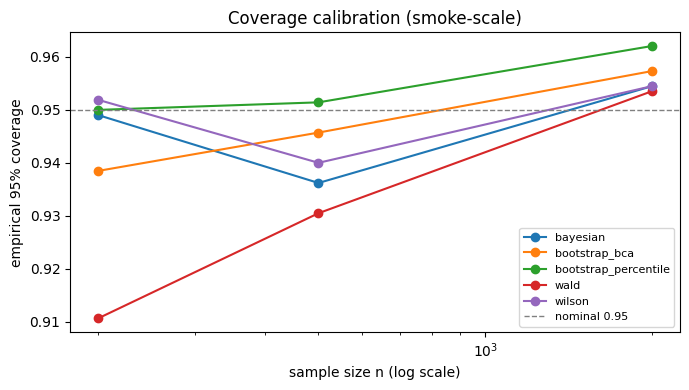

In [7]:
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 4))
    for method, sub in summary.groupby('method'):
        ax.plot(sub['n'], sub['empirical_coverage'], marker='o', label=method)
    ax.axhline(0.95, color='gray', linestyle='--', linewidth=1, label='nominal 0.95')
    ax.set_xscale('log')
    ax.set_xlabel('sample size n (log scale)')
    ax.set_ylabel('empirical 95% coverage')
    ax.set_title('Coverage calibration (smoke-scale)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
except ImportError:
    print('matplotlib not installed; skipping plot')

## What this tells us

- A method with empirical coverage close to the nominal 0.95 is well-calibrated for this DGP at that sample size.
- Under-coverage (< 0.95) is a sign that the method's interval is too narrow.
- Width should shrink as `n` grows, but **only as fast as `1/√n`** for well-behaved methods.

Re-run with `N_REPLICATES = 500` (and the production sample sizes) for article-grade numbers. The CSVs in `article/results/` are the canonical inputs to the article's coverage table (`article/tables/table3_coverage.py`) and B&W figure (`notebooks/article/figures/fig5_coverage_calibration.ipynb`).